In [1]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=5c66ee318cfc6760b7a8223baeb69ad4cafd3fd64745324340bcd6719b80b363
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# urls = ["https://zenodo.org/records/5776219/files/Urban_intersection_4.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Urban_intersection_3.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Urban_intersection_2.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Urban_intersection_1.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Split_roundabout.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Rural_road.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Roundabout(Near)_3.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Roundabout(Near)_2.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Roundabout(Near)_1.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Roundabout(Far)_2.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Roundabout(Far)_1.zip?download=1",
#      "https://zenodo.org/records/5776219/files/Regional_road.zip?download=1",
#      ]
urls = ["https://zenodo.org/records/5776219/files/Roundabout(Near)_3.zip?download=1"]

In [4]:
import wget
import zipfile
import os
def download(url, data_name, data_folder='',extract = True):
    try:
        # Ensure the target folder exists
        os.makedirs(data_folder, exist_ok=True)

        zip_path = os.path.join(data_folder, f"{data_name}.zip")

        # Check if the ZIP file already exists
        if os.path.exists(zip_path):
            print(f"File '{zip_path}' already exists. Skipping download.")
        else:
            print(f"Downloading {zip_path}...")
            wget.download(url, zip_path)

        if extract:
            extract_path = os.path.join(data_folder, data_name)

            # Extract the ZIP file if not already extracted
            if not os.path.exists(extract_path):
                print(f"\nExtracting {zip_path}...")
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_path)
            else:
                print(f"Folder '{extract_path}' already exists. Skipping extraction.")

        # return data_name

    except Exception as e:
        return str(e)


In [5]:
data_folder = '/content/dataset'
for i, url in enumerate(urls):
    data_name = url.replace('.zip?download=1', '').split('/')[-1]
    print(f"Processing dataset {i}: {data_name}")

    download(url,data_name,data_folder,extract=False)

Processing dataset 0: Roundabout(Near)_3


In [6]:
import os
import zipfile

# Zip files source directory on Drive
dataset_dir = '/content/dataset/'

# Extraction target directory in Colab local storage
extract_to = '/content/dataset/'
os.makedirs(extract_to, exist_ok=True)

# List all zip files in Drive dataset directory
zip_files = [f for f in os.listdir(dataset_dir) if f.endswith('.zip')]

for zip_file in zip_files:
    zip_path = os.path.join(dataset_dir, zip_file)  # Use correct source path
    print(f"Extracting {zip_file}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)  # Extract to /content/dataset
print("Extraction done.")


Extracting Roundabout(Near)_3.zip...
Extraction done.


In [7]:
import os
import shutil
import glob
import tqdm
import hashlib
import json

# Class mapping
standard_class_map = {
    'car': 'car',
    'motorbike': 'motorbike',
    'motorcycle': 'motorbike',
    'moto': 'motorbike'
}
CLASS_MAP = {'car': 0, 'motorbike': 1}

# Directories
dataset_root = 'dataset'
base_output_dir = '/content/splitted_dataset'
split_file_path = os.path.join('/content/drive/MyDrive/MS_Passau_Thesis/Multi_Encoder_Vehicle_Detection/dataset', 'split_map.json')
img_exts = ['.jpg', '.jpeg', '.png']

# Output split dirs
splits = ['train', 'val', 'test']
for split in splits:
    os.makedirs(os.path.join(base_output_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(base_output_dir, split, 'labels'), exist_ok=True)

folders = [f for f in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, f))]

# Load or generate split map
split_map_json = {'train': [], 'val': [], 'test': []}
file_to_split = {}

def assign_split_hash(file_path, val_ratio=0.2, test_ratio=0.1):
    h = int(hashlib.sha1(file_path.encode()).hexdigest(), 16)
    percent = (h % 1000) / 1000.0
    if percent < test_ratio:
        return 'test'
    elif percent < test_ratio + val_ratio:
        return 'val'
    return 'train'

# Load split_map.json if it exists
if os.path.exists(split_file_path):
    with open(split_file_path, 'r') as f:
        split_map_json = json.load(f)
        for split in splits:
            for path in split_map_json[split]:
                file_to_split[path] = split

new_assignments = False

for folder in folders:
    print('Processing:',folder)
    obj_names_paths = glob.glob(os.path.join(dataset_root, folder, '**', 'obj.names'), recursive=True)
    if not obj_names_paths:
        continue

    obj_names_path = obj_names_paths[0]
    label_folder = obj_names_path.replace('obj.names', 'obj_train_data')

    with open(obj_names_path, 'r') as f:
        lines = [l.strip().lower() for l in f.readlines()]
        folder_map = {}
        for i, cls in enumerate(lines):
            std_cls = standard_class_map.get(cls)
            if std_cls in CLASS_MAP:
                folder_map[i] = CLASS_MAP[std_cls]

    image_files = [f for f in os.listdir(label_folder) if os.path.splitext(f)[1].lower() in img_exts]

    for img_file in tqdm.tqdm(image_files, desc=f"  Processing {folder}"):
        full_img_path = os.path.join(label_folder, img_file)
        full_lbl_path = os.path.splitext(full_img_path)[0] + '.txt'

        if not os.path.exists(full_lbl_path):
            continue

        # Determine split (load or assign)
        if full_img_path in file_to_split:
            split = file_to_split[full_img_path]
        else:
            split = assign_split_hash(full_img_path)
            split_map_json[split].append(full_img_path)
            file_to_split[full_img_path] = split
            new_assignments = True

        # Process label content
        label_lines = []
        with open(full_lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                old_id = int(parts[0])
                if old_id in folder_map:
                    new_id = folder_map[old_id]
                    label_lines.append(' '.join([str(new_id)] + parts[1:]))

        if label_lines:
            # Save using a stable name (e.g., hash or basename with folder)
            base_name = hashlib.md5(full_img_path.encode()).hexdigest()  # unique, consistent name
            img_out_path = os.path.join(base_output_dir, split, 'images', base_name + '.jpg')
            lbl_out_path = os.path.join(base_output_dir, split, 'labels', base_name + '.txt')

            shutil.copy(full_img_path, img_out_path)
            with open(lbl_out_path, 'w') as out_f:
                out_f.write('\n'.join(label_lines))

# Save updated split_map.json
if new_assignments:
    with open(split_file_path, 'w') as f:
        json.dump(split_map_json, f, indent=2)

# Save class names and data.yaml
with open(os.path.join(base_output_dir, 'obj.names'), 'w') as f:
    f.write("car\nmotorbike")

with open(os.path.join(base_output_dir, 'data.yaml'), 'w') as f:
    f.write(f"""train: {base_output_dir}/train/images
val: {base_output_dir}/val/images
test: {base_output_dir}/test/images
nc: 2
names: ['car', 'motorbike']
""")


Processing: Roundabout(Near)_3


  Processing Roundabout(Near)_3: 100%|██████████| 342/342 [00:02<00:00, 124.34it/s]


In [8]:
import os
import random
import cv2
import matplotlib.pyplot as plt

def vis_data(split_name, base_dir):

  img_dir = os.path.join(base_dir, split_name, 'images')
  lbl_dir = os.path.join(base_dir, split_name, 'labels')

  # Class names
  classes = ['car', 'motorbike']

  # Load 9 random images
  all_images = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
  sample_images = random.sample(all_images, min(9, len(all_images)))

  fig, axs = plt.subplots(3, 3, figsize=(15, 15))
  fig.suptitle(f'{split_name.upper()} SAMPLES WITH BOUNDING BOXES', fontsize=18)

  for ax, img_file in zip(axs.flatten(), sample_images):
      img_path = os.path.join(img_dir, img_file)
      lbl_path = os.path.join(lbl_dir, img_file.replace('.png', '.txt'))

      img = cv2.imread(img_path)
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      height, width = img.shape[:2]

      # Draw boxes
      if os.path.exists(lbl_path):
          with open(lbl_path, 'r') as f:
              for line in f:
                  parts = line.strip().split()
                  cls_id = int(parts[0])
                  x_center, y_center, w, h = map(float, parts[1:])

                  # Convert from YOLO format to box coordinates
                  x1 = int((x_center - w / 2) * width)
                  y1 = int((y_center - h / 2) * height)
                  x2 = int((x_center + w / 2) * width)
                  y2 = int((y_center + h / 2) * height)

                  cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                  cv2.putText(img, classes[cls_id], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX,
                              0.6, (255, 0, 0), 2)

      ax.imshow(img)
      ax.set_title(img_file)
      ax.axis('off')

  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()


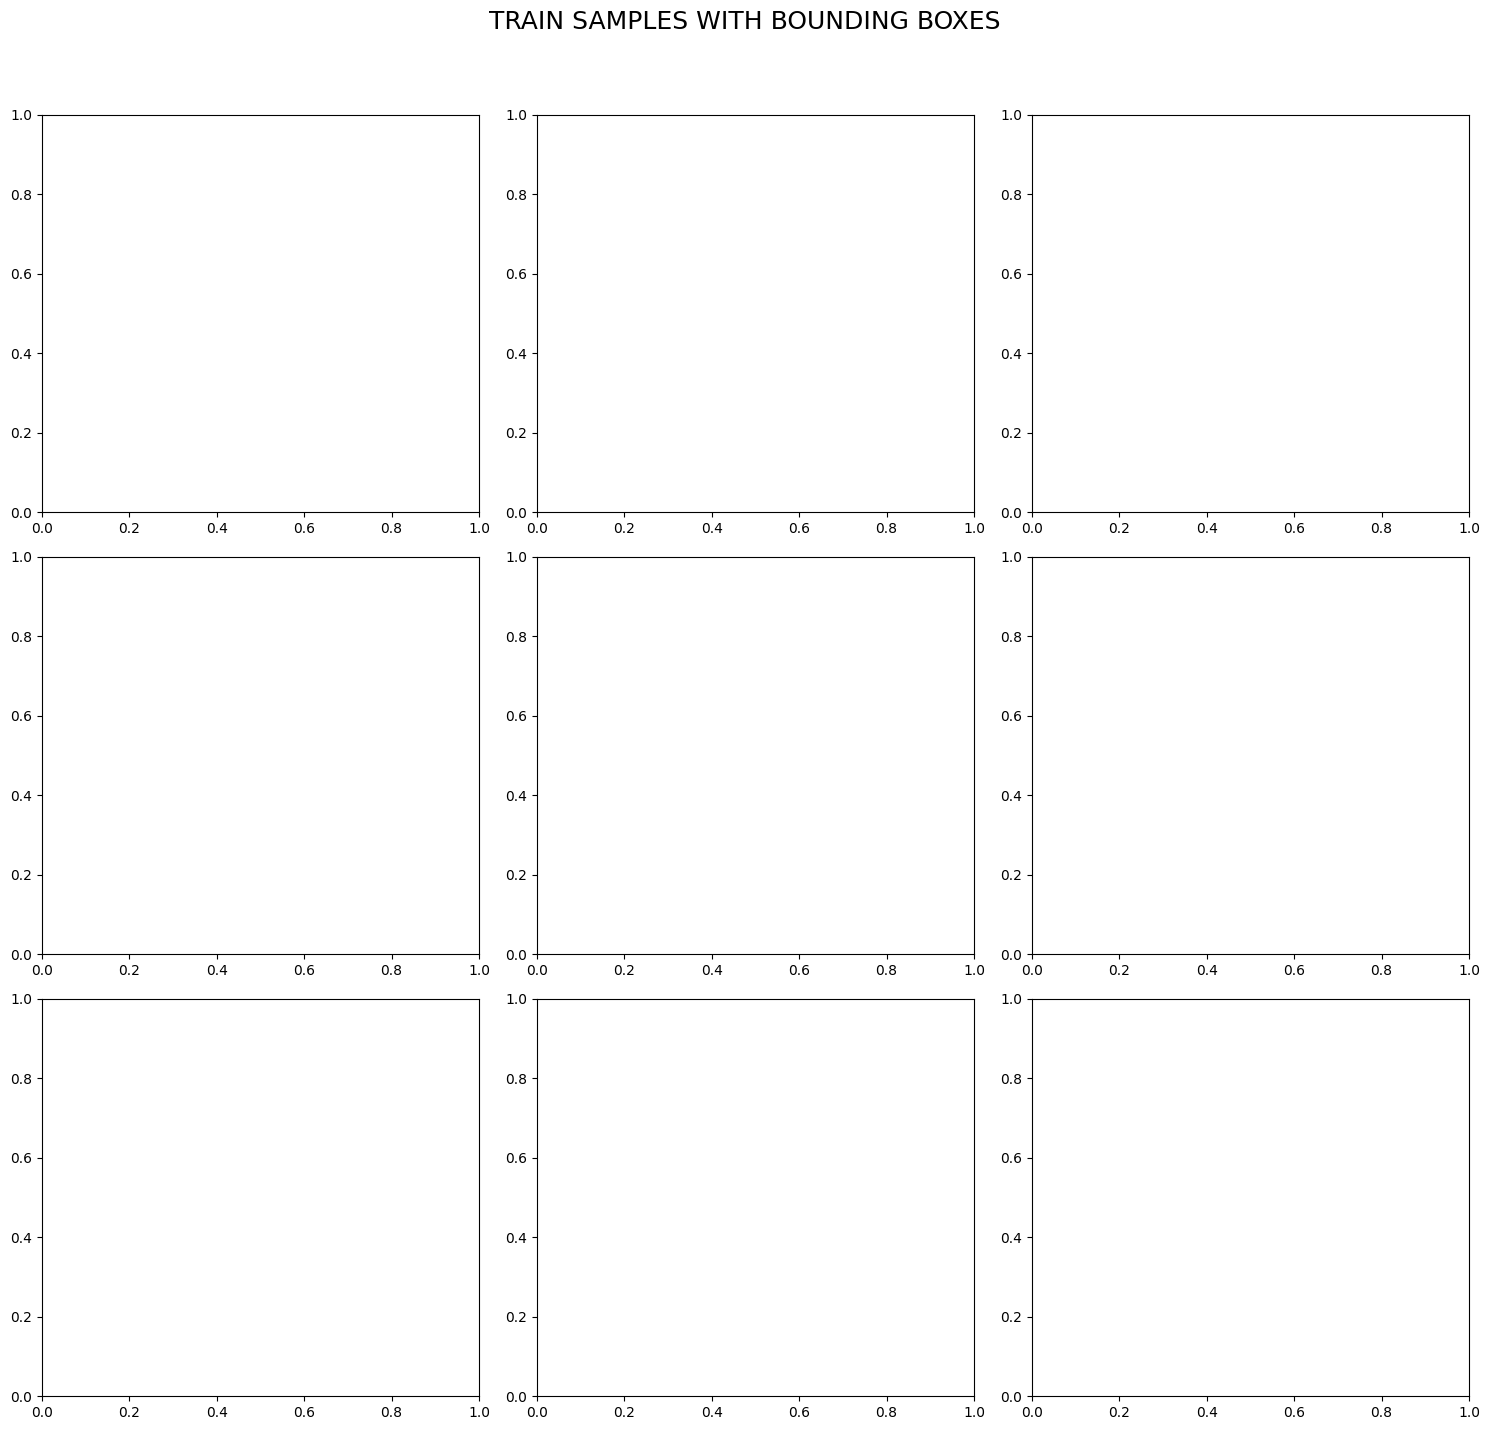

In [9]:
split_name = 'train'
base_dir = 'splitted_dataset'
vis_data(split_name, base_dir)

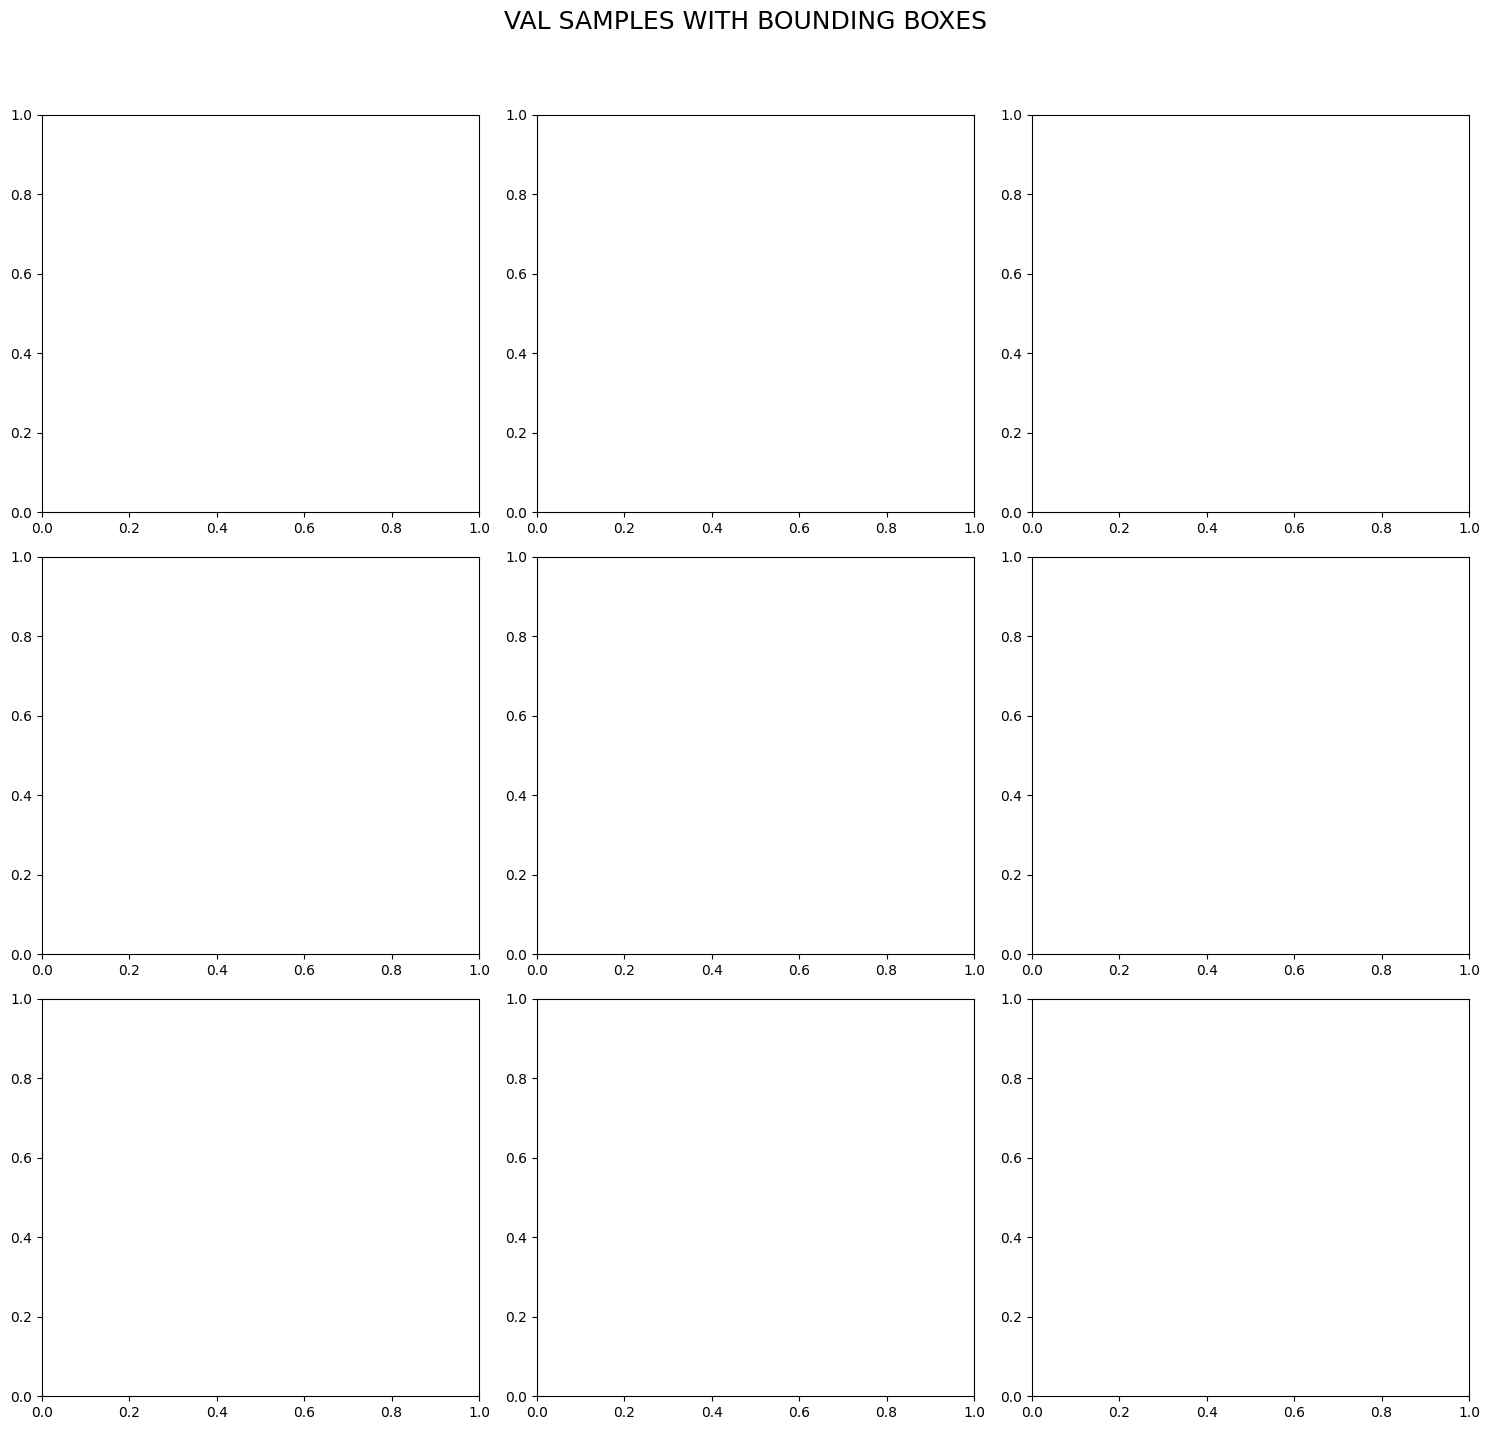

In [10]:

split_name = 'val'
base_dir = 'splitted_dataset'
vis_data(split_name, base_dir)

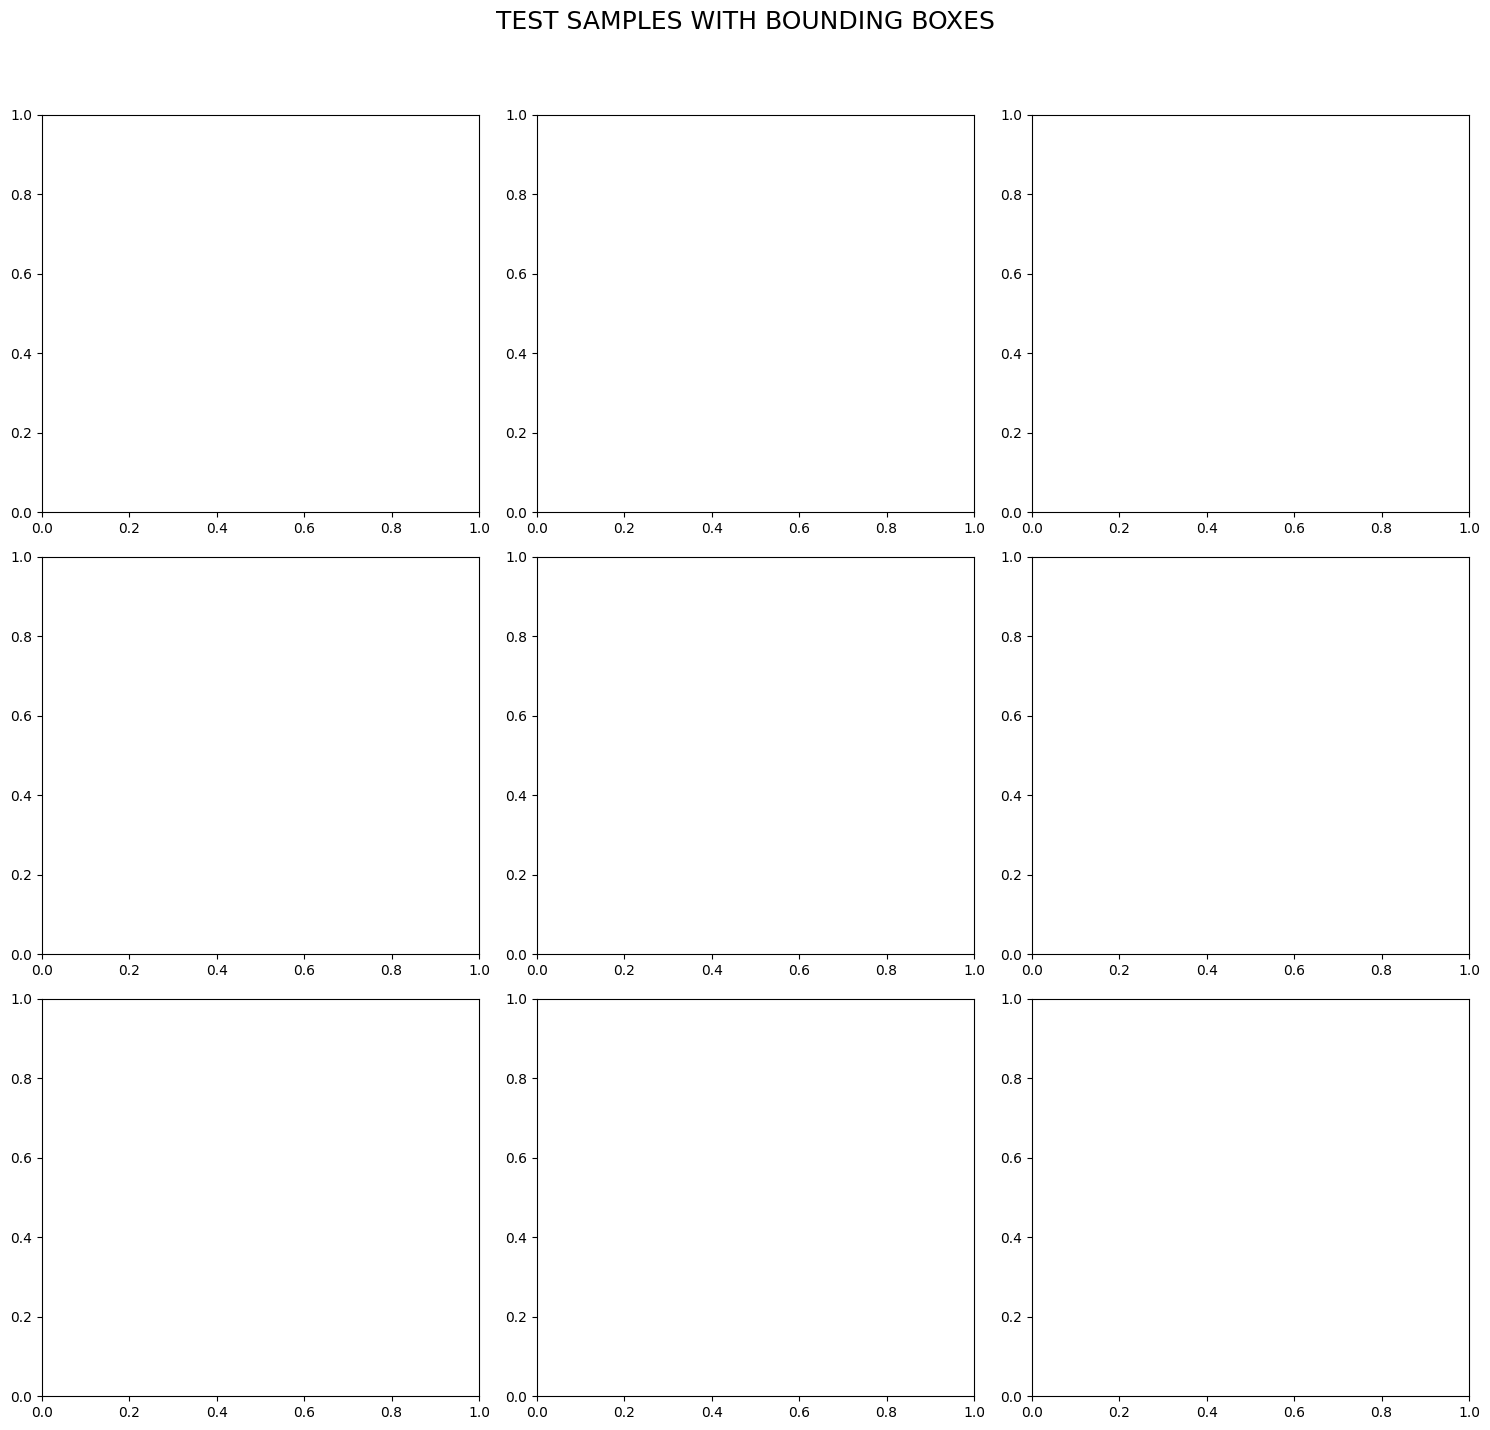

In [11]:

split_name = 'test'
base_dir = 'splitted_dataset'
vis_data(split_name, base_dir)

In [12]:
!zip -r "/content/drive/MyDrive/MS_Passau_Thesis/Multi_Encoder_Vehicle_Detection/dataset/Roundabout_Near3.zip" splitted_dataset

  adding: splitted_dataset/ (stored 0%)
  adding: splitted_dataset/obj.names (stored 0%)
  adding: splitted_dataset/test/ (stored 0%)
  adding: splitted_dataset/test/labels/ (stored 0%)
  adding: splitted_dataset/test/labels/frame_000200.txt (deflated 56%)
  adding: splitted_dataset/test/labels/frame_000155.txt (deflated 57%)
  adding: splitted_dataset/test/labels/frame_000168.txt (deflated 57%)
  adding: splitted_dataset/test/labels/frame_000110.txt (deflated 57%)
  adding: splitted_dataset/test/labels/frame_000108.txt (deflated 57%)
  adding: splitted_dataset/test/labels/frame_000105.txt (deflated 57%)
  adding: splitted_dataset/test/labels/frame_000248.txt (deflated 57%)
  adding: splitted_dataset/test/labels/frame_000338.txt (deflated 56%)
  adding: splitted_dataset/test/labels/frame_000220.txt (deflated 56%)
  adding: splitted_dataset/test/labels/frame_000126.txt (deflated 58%)
  adding: splitted_dataset/test/labels/frame_000193.txt (deflated 57%)
  adding: splitted_dataset/test/l